In [151]:
import pandas as pd
import numpy as np

In [152]:
data = pd.read_csv("../bitcoin_data/raw/btc_3h.csv")

In [153]:
data.head()

,datetime,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667


##### Functions

In [ ]:
def compute_rsi(close, window=14):
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def compute_atr(df, window=14):
    high_low = df["high"] - df["low"]
    high_close = (df["high"] - df["close"].shift(1)).abs()
    low_close = (df["low"] - df["close"].shift(1)).abs()

    true_range = pd.concat(
        [high_low, high_close, low_close],
        axis=1
    ).max(axis=1)

    atr = true_range.rolling(window).mean()

    return atr


def rolling_zscore(series, window):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()

    return (series - mean) / std

In [155]:
def create_btc_indicators(df):
    df = df.copy()
    df = df.sort_index()

    # ----------------------------
    # Price return indicators
    # ----------------------------
    df["log_close"] = np.log(df["close"])

    for h in [1, 2, 3, 5, 7, 14, 21, 30]:
        df[f"log_return_{h}d"] = df["log_close"].diff(h)
        df[f"pct_return_{h}d"] = df["close"].pct_change(h)

    # ----------------------------
    # Moving averages
    # ----------------------------
    for window in [7, 14, 20, 30, 50, 100, 200]:
        df[f"sma_{window}"] = df["close"].rolling(window).mean()
        df[f"ema_{window}"] = df["close"].ewm(span=window, adjust=False).mean()

        df[f"close_to_sma_{window}"] = df["close"] / df[f"sma_{window}"] - 1
        df[f"close_to_ema_{window}"] = df["close"] / df[f"ema_{window}"] - 1

        df[f"sma_{window}_slope"] = df[f"sma_{window}"].pct_change(5)
        df[f"ema_{window}_slope"] = df[f"ema_{window}"].pct_change(5)

    # Moving average crossover indicators
    df["sma_20_above_50"] = (df["sma_20"] > df["sma_50"]).astype(int)
    df["sma_50_above_200"] = (df["sma_50"] > df["sma_200"]).astype(int)
    df["ema_20_above_50"] = (df["ema_20"] > df["ema_50"]).astype(int)

    # ----------------------------
    # RSI
    # ----------------------------
    df["rsi_14"] = compute_rsi(df["close"], window=14)

    df["rsi_overbought"] = (df["rsi_14"] > 70).astype(int)
    df["rsi_oversold"] = (df["rsi_14"] < 30).astype(int)

    # ----------------------------
    # MACD
    # ----------------------------
    ema_12 = df["close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["close"].ewm(span=26, adjust=False).mean()

    df["macd"] = ema_12 - ema_26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]

    df["macd_bullish"] = (df["macd"] > df["macd_signal"]).astype(int)

    # ----------------------------
    # Volatility indicators
    # ----------------------------
    for window in [7, 14, 21, 30, 60, 90]:
        df[f"realized_vol_{window}d"] = df["log_return_1d"].rolling(window).std()
        df[f"realized_vol_{window}d_ann"] = df[f"realized_vol_{window}d"] * np.sqrt(365)

    df["atr_14"] = compute_atr(df, window=14)
    df["atr_pct_14"] = df["atr_14"] / df["close"]

    df["daily_range"] = df["high"] - df["low"]
    df["daily_range_pct"] = df["daily_range"] / df["close"]

    df["close_position_in_range"] = (
        (df["close"] - df["low"]) / (df["high"] - df["low"])
    )

    # ----------------------------
    # Bollinger Bands
    # ----------------------------
    bb_window = 20

    df["bb_middle"] = df["close"].rolling(bb_window).mean()
    bb_std = df["close"].rolling(bb_window).std()

    df["bb_upper"] = df["bb_middle"] + 2 * bb_std
    df["bb_lower"] = df["bb_middle"] - 2 * bb_std

    df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["bb_middle"]

    df["bb_percent_b"] = (
        (df["close"] - df["bb_lower"]) /
        (df["bb_upper"] - df["bb_lower"])
    )

    df["price_above_bb_upper"] = (df["close"] > df["bb_upper"]).astype(int)
    df["price_below_bb_lower"] = (df["close"] < df["bb_lower"]).astype(int)

    # ----------------------------
    # Drawdown and breakout indicators
    # ----------------------------
    for window in [30, 60, 90, 180, 365]:
        rolling_high = df["close"].rolling(window).max()
        rolling_low = df["close"].rolling(window).min()

        df[f"drawdown_from_{window}d_high"] = df["close"] / rolling_high - 1
        df[f"distance_from_{window}d_low"] = df["close"] / rolling_low - 1

        df[f"breakout_{window}d_high"] = (
            df["close"] >= rolling_high.shift(1)
        ).astype(int)

        df[f"breakdown_{window}d_low"] = (
            df["close"] <= rolling_low.shift(1)
        ).astype(int)

    # ----------------------------
    # Volume indicators
    # ----------------------------
    df["volume_log"] = np.log1p(df["volume"])

    for window in [7, 14, 30, 60, 90]:
        df[f"volume_sma_{window}"] = df["volume"].rolling(window).mean()
        df[f"volume_z_{window}d"] = rolling_zscore(df["volume_log"], window)
        df[f"volume_change_{window}d"] = df["volume"].pct_change(window)

    df["volume_above_30d_avg"] = (
        df["volume"] > df["volume_sma_30"]
    ).astype(int)

    df["volume_to_volatility"] = (
        df["volume_z_30d"] / df["realized_vol_30d"]
    )

    # ----------------------------
    # Seasonality indicators
    # ----------------------------
    #df["day_of_week"] = df.index.dayofweek
    #df["month"] = df.index.month
    #df["quarter"] = df.index.quarter
    #df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    #df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    #df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    #df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    #df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # ----------------------------
    # Clean infinite values
    # ----------------------------
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [156]:
btc_indicators = create_btc_indicators(data)

print(btc_indicators.tail())
print(btc_indicators.shape)

                  datetime      open      high       low     close  \
18656  2026-05-21 09:00:00  77924.63  77977.53  77147.15  77189.10   
18657  2026-05-21 12:00:00  77189.10  77363.32  76719.47  76984.61   
18658  2026-05-21 15:00:00  76984.61  78098.16  76900.00  77869.38   
18659  2026-05-21 18:00:00  77869.38  77922.01  77230.00  77705.81   
18660  2026-05-21 21:00:00  77705.80  77813.35  77705.80  77780.37   

           volume  log_close  log_return_1d  pct_return_1d  log_return_2d  \
18656  1441.40032  11.254014      -0.009484      -0.009439      -0.008243   
18657  1942.79991  11.251361      -0.002653      -0.002649      -0.012137   
18658  2107.40302  11.262788       0.011427       0.011493       0.008775   
18659  1141.78197  11.260685      -0.002103      -0.002101       0.009324   
18660   101.88650  11.261644       0.000959       0.000960      -0.001144   

       ...  volume_z_30d  volume_change_30d  volume_sma_60  volume_z_60d  \
18656  ...     -0.064828           1.241

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_2883/2124607524.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"breakout_{window}d_high"] = (
/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_2883/2124607524.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"breakdown_{window}d_low"] = (
/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_2883/2124607524.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

* See only indicator columns

In [157]:
raw_cols = ["open", "high", "low", "close", "volume"]

indicator_cols = [
    col for col in btc_indicators.columns
    if col not in raw_cols
]

print("Number of indicators:", len(indicator_cols))
print(indicator_cols)

Number of indicators: 132
['datetime', 'log_close', 'log_return_1d', 'pct_return_1d', 'log_return_2d', 'pct_return_2d', 'log_return_3d', 'pct_return_3d', 'log_return_5d', 'pct_return_5d', 'log_return_7d', 'pct_return_7d', 'log_return_14d', 'pct_return_14d', 'log_return_21d', 'pct_return_21d', 'log_return_30d', 'pct_return_30d', 'sma_7', 'ema_7', 'close_to_sma_7', 'close_to_ema_7', 'sma_7_slope', 'ema_7_slope', 'sma_14', 'ema_14', 'close_to_sma_14', 'close_to_ema_14', 'sma_14_slope', 'ema_14_slope', 'sma_20', 'ema_20', 'close_to_sma_20', 'close_to_ema_20', 'sma_20_slope', 'ema_20_slope', 'sma_30', 'ema_30', 'close_to_sma_30', 'close_to_ema_30', 'sma_30_slope', 'ema_30_slope', 'sma_50', 'ema_50', 'close_to_sma_50', 'close_to_ema_50', 'sma_50_slope', 'ema_50_slope', 'sma_100', 'ema_100', 'close_to_sma_100', 'close_to_ema_100', 'sma_100_slope', 'ema_100_slope', 'sma_200', 'ema_200', 'close_to_sma_200', 'close_to_ema_200', 'sma_200_slope', 'ema_200_slope', 'sma_20_above_50', 'sma_50_above_2

* Drop Missing columns

In [158]:
btc_indicators_clean = btc_indicators.dropna()

print(btc_indicators_clean.tail())
print(btc_indicators_clean.shape)

                  datetime      open      high       low     close  \
18656  2026-05-21 09:00:00  77924.63  77977.53  77147.15  77189.10   
18657  2026-05-21 12:00:00  77189.10  77363.32  76719.47  76984.61   
18658  2026-05-21 15:00:00  76984.61  78098.16  76900.00  77869.38   
18659  2026-05-21 18:00:00  77869.38  77922.01  77230.00  77705.81   
18660  2026-05-21 21:00:00  77705.80  77813.35  77705.80  77780.37   

           volume  log_close  log_return_1d  pct_return_1d  log_return_2d  \
18656  1441.40032  11.254014      -0.009484      -0.009439      -0.008243   
18657  1942.79991  11.251361      -0.002653      -0.002649      -0.012137   
18658  2107.40302  11.262788       0.011427       0.011493       0.008775   
18659  1141.78197  11.260685      -0.002103      -0.002101       0.009324   
18660   101.88650  11.261644       0.000959       0.000960      -0.001144   

       ...  volume_z_30d  volume_change_30d  volume_sma_60  volume_z_60d  \
18656  ...     -0.064828           1.241

##### Create target feature

In [159]:
target = "future_price_1d"

bad_cols = [
    "future_price_1d",
    "datetime",
    "date"
]

feature_cols = [
    col for col in df.columns
    if col not in bad_cols
]

feature_cols = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

print("Number of usable features:", len(feature_cols))
print(feature_cols)

Number of usable features: 136
['open', 'high', 'low', 'close', 'volume', 'log_close', 'log_return_1d', 'pct_return_1d', 'log_return_2d', 'pct_return_2d', 'log_return_3d', 'pct_return_3d', 'log_return_5d', 'pct_return_5d', 'log_return_7d', 'pct_return_7d', 'log_return_14d', 'pct_return_14d', 'log_return_21d', 'pct_return_21d', 'log_return_30d', 'pct_return_30d', 'sma_7', 'ema_7', 'close_to_sma_7', 'close_to_ema_7', 'sma_7_slope', 'ema_7_slope', 'sma_14', 'ema_14', 'close_to_sma_14', 'close_to_ema_14', 'sma_14_slope', 'ema_14_slope', 'sma_20', 'ema_20', 'close_to_sma_20', 'close_to_ema_20', 'sma_20_slope', 'ema_20_slope', 'sma_30', 'ema_30', 'close_to_sma_30', 'close_to_ema_30', 'sma_30_slope', 'ema_30_slope', 'sma_50', 'ema_50', 'close_to_sma_50', 'close_to_ema_50', 'sma_50_slope', 'ema_50_slope', 'sma_100', 'ema_100', 'close_to_sma_100', 'close_to_ema_100', 'sma_100_slope', 'ema_100_slope', 'sma_200', 'ema_200', 'close_to_sma_200', 'close_to_ema_200', 'sma_200_slope', 'ema_200_slope',

In [160]:
target = "future_return_1d"

* Time-Based Train Test Split

In [161]:
# Make sure df is your indicator dataframe
df = btc_indicators_clean.copy()

# If datetime exists as a column, set it as index
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime")

df = df.sort_index()

# Create your only target
df["future_price_1d"] = df["close"].shift(-1)

# Remove rows where target is unknown
df = df.dropna(subset=["future_price_1d"])

print("future_price_7d" in df.columns)
print(df[["close", "future_price_1d"]].tail())

False
                        close  future_price_1d
datetime                                      
2026-05-21 06:00:00  77924.63         77189.10
2026-05-21 09:00:00  77189.10         76984.61
2026-05-21 12:00:00  76984.61         77869.38
2026-05-21 15:00:00  77869.38         77705.81
2026-05-21 18:00:00  77705.81         77780.37


In [162]:
target = "future_price_1d"

feature_cols = [
    col for col in df.columns
    if col not in ["future_price_1d", "datetime", "date"]
]

feature_cols = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

X = df[feature_cols]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:", target)

X shape: (18296, 136)
y shape: (18296,)
Target: future_price_1d


In [163]:
split_date = "2025-01-01"

X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]

X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14249, 136)
X_test: (4047, 136)
y_train: (14249,)
y_test: (4047,)


In [164]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge

* Baseline Model

In [165]:
baseline_pred = X_test["close"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mape = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline MAPE:", round(baseline_mape, 2), "%")

Baseline MAE: 503.54
Baseline RMSE: 759.74
Baseline MAPE: 0.55 %


* Evaluation Function

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_price_model(name, model, X_test, y_test):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    r2 = r2_score(y_test, pred)

    current_price = X_test["close"]

    direction_accuracy = np.mean(
        np.sign(y_test - current_price) == np.sign(pred - current_price)
    ) * 100

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2,
        "direction_accuracy_%": direction_accuracy
    }

* Random Forest Model

In [167]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_result = evaluate_price_model(
    "RandomForest",
    rf_model,
    X_test,
    y_test
)

rf_result

{'model': 'RandomForest',
 'MAE': 3513.234244130195,
 'RMSE': np.float64(5460.375682330431),
 'MAPE_%': np.float64(3.427229408510858),
 'R2': 0.8801454504014211,
 'direction_accuracy_%': np.float64(50.28416110699283)}

* XGBoost Model

In [168]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_result = evaluate_price_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)

xgb_result

{'model': 'XGBoost',
 'MAE': 4404.799862011983,
 'RMSE': np.float64(6434.485395992751),
 'MAPE_%': np.float64(4.256200459431629),
 'R2': 0.8335678913860708,
 'direction_accuracy_%': np.float64(50.90190264393378)}

* HistGradientBoosting Model

In [169]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=600,
    learning_rate=0.03,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb_model.fit(X_train, y_train)

hgb_result = evaluate_price_model(
    "HistGradientBoosting",
    hgb_model,
    X_test,
    y_test
)

hgb_result

{'model': 'HistGradientBoosting',
 'MAE': 4562.435915193488,
 'RMSE': np.float64(6619.227424712534),
 'MAPE_%': np.float64(4.444454738216842),
 'R2': 0.8238737524661716,
 'direction_accuracy_%': np.float64(50.35829009142575)}

* Compare the Three tree Models

In [170]:
results_df = pd.DataFrame([
    rf_result,
    xgb_result,
    hgb_result
]).sort_values("MAE")

results_df

,model,MAE,RMSE,MAPE_%,R2,direction_accuracy_%
0,RandomForest,3513.234244,5460.375682,3.427229,0.880145,50.284161
1,XGBoost,4404.799862,6434.485396,4.256200,0.833568,50.901903
2,HistGradientBoosting,4562.435915,6619.227425,4.444455,0.823874,50.358290


In [171]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
hgb_pred = hgb_model.predict(X_test)

comparison_df = pd.DataFrame(index=X_test.index)

comparison_df["current_close"] = X_test["close"]
comparison_df["actual_future_price_1d"] = y_test

comparison_df["rf_predicted_price_1d"] = rf_pred
comparison_df["xgb_predicted_price_1d"] = xgb_pred
comparison_df["hgb_predicted_price_1d"] = hgb_pred

comparison_df["rf_error"] = comparison_df["actual_future_price_1d"] - comparison_df["rf_predicted_price_1d"]
comparison_df["xgb_error"] = comparison_df["actual_future_price_1d"] - comparison_df["xgb_predicted_price_1d"]
comparison_df["hgb_error"] = comparison_df["actual_future_price_1d"] - comparison_df["hgb_predicted_price_1d"]

comparison_df["rf_move_pct"] = (comparison_df["rf_predicted_price_1d"] / comparison_df["current_close"] - 1) * 100
comparison_df["xgb_move_pct"] = (comparison_df["xgb_predicted_price_1d"] / comparison_df["current_close"] - 1) * 100
comparison_df["hgb_move_pct"] = (comparison_df["hgb_predicted_price_1d"] / comparison_df["current_close"] - 1) * 100

comparison_df.tail(20)

,current_close,actual_future_price_1d,rf_predicted_price_1d,xgb_predicted_price_1d,hgb_predicted_price_1d,rf_error,xgb_error,hgb_error,rf_move_pct,xgb_move_pct,hgb_move_pct
datetime,,,,,,,,,,,
2026-05-19 09:00:00,76714.62,76392.43,80278.723477,77582.859375,76041.317149,-3886.293477,-1190.429375,351.112851,4.645925,1.131778,-0.877672
2026-05-19 12:00:00,76392.43,76856.76,80087.479479,77621.210938,76092.008750,-3230.719479,-764.450938,764.751250,4.836931,1.608511,-0.393260
2026-05-19 15:00:00,76856.76,77022.23,80099.680330,77679.859375,76149.553295,-3077.450330,-657.629375,872.676705,4.219434,1.070952,-0.920162
2026-05-19 18:00:00,77022.23,76834.36,80249.379593,77593.148438,76389.991259,-3415.019593,-758.788437,444.368741,4.189894,0.741239,-0.820852
2026-05-19 21:00:00,76834.36,76690.42,80215.034883,77549.203125,76130.261959,-3524.614883,-858.783125,560.158041,4.399952,0.930369,-0.916384
2026-05-20 00:00:00,76690.42,77196.99,80220.287121,77522.773438,76117.773702,-3023.297121,-325.783437,1079.216298,4.602748,1.085342,-0.746699
2026-05-20 03:00:00,77196.99,77458.04,80240.727334,77636.085938,76137.227430,-2782.687334,-178.045938,1320.812570,3.942819,0.568799,-1.372803
2026-05-20 06:00:00,77458.04,77382.49,80277.306825,77526.468750,76266.241918,-2894.816825,-143.978750,1116.248082,3.639734,0.088343,-1.538637
2026-05-20 09:00:00,77382.49,77446.08,80272.054586,77545.890625,76141.898207,-2825.974586,-99.810625,1304.181793,3.734132,0.211160,-1.603194


In [172]:
def evaluate_model(name, y_true, y_pred, current_close):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    direction_accuracy = np.mean(
        np.sign(y_true - current_close) == np.sign(y_pred - current_close)
    ) * 100

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2,
        "direction_accuracy_%": direction_accuracy
    }

In [173]:
current_close_test = X_test["close"]

results_df = pd.DataFrame([
    evaluate_model("RandomForest", y_test, rf_pred, current_close_test),
    evaluate_model("XGBoost", y_test, xgb_pred, current_close_test),
    evaluate_model("HistGradientBoosting", y_test, hgb_pred, current_close_test)
]).sort_values("MAPE_%")

results_df

,model,MAE,RMSE,MAPE_%,R2,direction_accuracy_%
0,RandomForest,3513.234244,5460.375682,3.427229,0.880145,50.284161
1,XGBoost,4404.799862,6434.485396,4.256200,0.833568,50.901903
2,HistGradientBoosting,4562.435915,6619.227425,4.444455,0.823874,50.358290


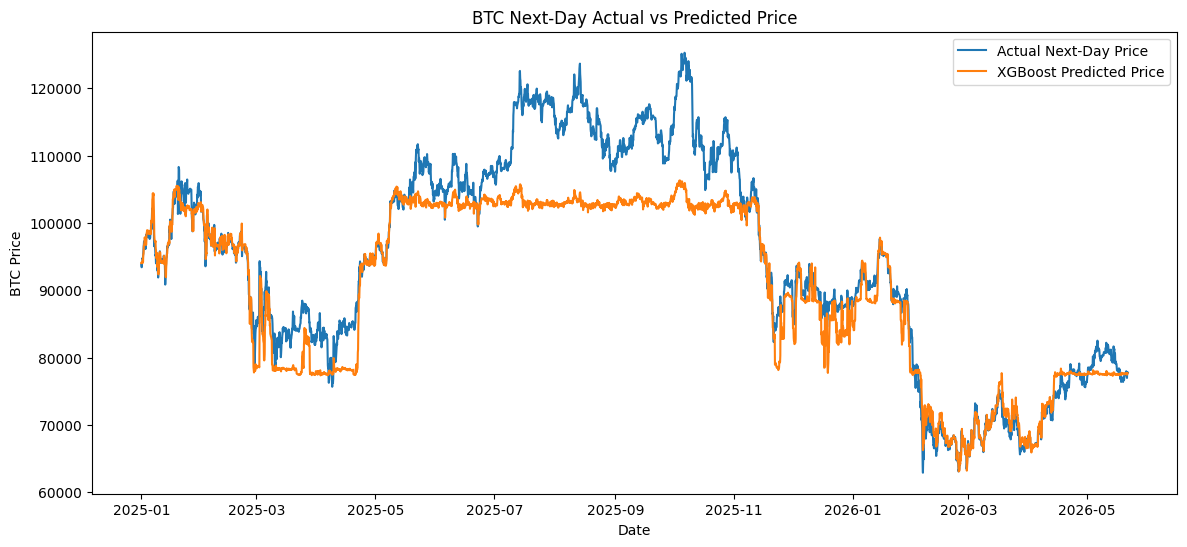

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(comparison_df.index, comparison_df["actual_future_price_1d"], label="Actual Next-Day Price")
plt.plot(comparison_df.index, comparison_df["xgb_predicted_price_1d"], label="XGBoost Predicted Price")
plt.title("BTC Next-Day Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

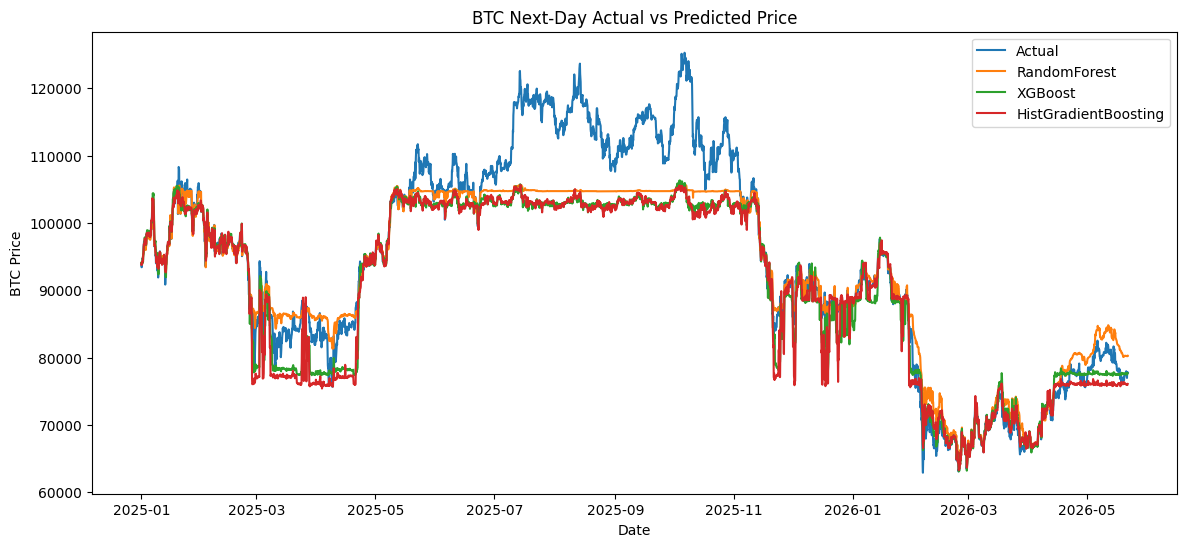

In [175]:
plt.figure(figsize=(14, 6))

plt.plot(comparison_df.index, comparison_df["actual_future_price_1d"], label="Actual")
plt.plot(comparison_df.index, comparison_df["rf_predicted_price_1d"], label="RandomForest")
plt.plot(comparison_df.index, comparison_df["xgb_predicted_price_1d"], label="XGBoost")
plt.plot(comparison_df.index, comparison_df["hgb_predicted_price_1d"], label="HistGradientBoosting")

plt.title("BTC Next-Day Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

In [176]:
latest_X = X.iloc[[-1]]
latest_date = latest_X.index[0]
current_price = latest_X["close"].iloc[0]

rf_next_price = rf_model.predict(latest_X)[0]
xgb_next_price = xgb_model.predict(latest_X)[0]
hgb_next_price = hgb_model.predict(latest_X)[0]

tomorrow_prediction = pd.DataFrame([{
    "date": latest_date,
    "current_price": current_price,

    "rf_next_day_price": rf_next_price,
    "xgb_next_day_price": xgb_next_price,
    "hgb_next_day_price": hgb_next_price,

    "rf_move_%": (rf_next_price / current_price - 1) * 100,
    "xgb_move_%": (xgb_next_price / current_price - 1) * 100,
    "hgb_move_%": (hgb_next_price / current_price - 1) * 100
}])

tomorrow_prediction.T

,0
date,2026-05-21 18:00:00
current_price,77705.81
rf_next_day_price,80291.426585
xgb_next_day_price,77666.984375
hgb_next_day_price,76097.500417
rf_move_%,3.327443
xgb_move_%,-0.049965
hgb_move_%,-2.069742


In [177]:
baseline_pred = X_test["close"]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mape = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_direction = np.mean(
    np.sign(y_test - X_test["close"]) == np.sign(baseline_pred - X_test["close"])
) * 100

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline MAPE:", round(baseline_mape, 2))
print("Baseline R2:", round(baseline_r2, 4))
print("Baseline Direction Accuracy:", round(baseline_direction, 2))

Baseline MAE: 503.54
Baseline RMSE: 759.74
Baseline MAPE: 0.55
Baseline R2: 0.9977
Baseline Direction Accuracy: 0.0


In [178]:
rf_pred = rf_model.predict(X_test)

comparison_df = pd.DataFrame(index=X_test.index)

comparison_df["current_close"] = X_test["close"]
comparison_df["actual_future_price_1d"] = y_test
comparison_df["rf_predicted_price_1d"] = rf_pred

comparison_df["actual_move_%"] = (
    comparison_df["actual_future_price_1d"] / comparison_df["current_close"] - 1
) * 100

comparison_df["predicted_move_%"] = (
    comparison_df["rf_predicted_price_1d"] / comparison_df["current_close"] - 1
) * 100

comparison_df["error_usd"] = (
    comparison_df["actual_future_price_1d"] - comparison_df["rf_predicted_price_1d"]
)

comparison_df["correct_direction"] = (
    np.sign(comparison_df["actual_future_price_1d"] - comparison_df["current_close"])
    ==
    np.sign(comparison_df["rf_predicted_price_1d"] - comparison_df["current_close"])
)

comparison_df.tail(20)

,current_close,actual_future_price_1d,rf_predicted_price_1d,actual_move_%,predicted_move_%,error_usd,correct_direction
datetime,,,,,,,
2026-05-19 09:00:00,76714.62,76392.43,80278.723477,-0.419985,4.645925,-3886.293477,False
2026-05-19 12:00:00,76392.43,76856.76,80087.479479,0.607822,4.836931,-3230.719479,True
2026-05-19 15:00:00,76856.76,77022.23,80099.680330,0.215297,4.219434,-3077.450330,True
2026-05-19 18:00:00,77022.23,76834.36,80249.379593,-0.243917,4.189894,-3415.019593,False
2026-05-19 21:00:00,76834.36,76690.42,80215.034883,-0.187338,4.399952,-3524.614883,False
2026-05-20 00:00:00,76690.42,77196.99,80220.287121,0.660539,4.602748,-3023.297121,True
2026-05-20 03:00:00,77196.99,77458.04,80240.727334,0.338161,3.942819,-2782.687334,True
2026-05-20 06:00:00,77458.04,77382.49,80277.306825,-0.097537,3.639734,-2894.816825,False
2026-05-20 09:00:00,77382.49,77446.08,80272.054586,0.082176,3.734132,-2825.974586,True


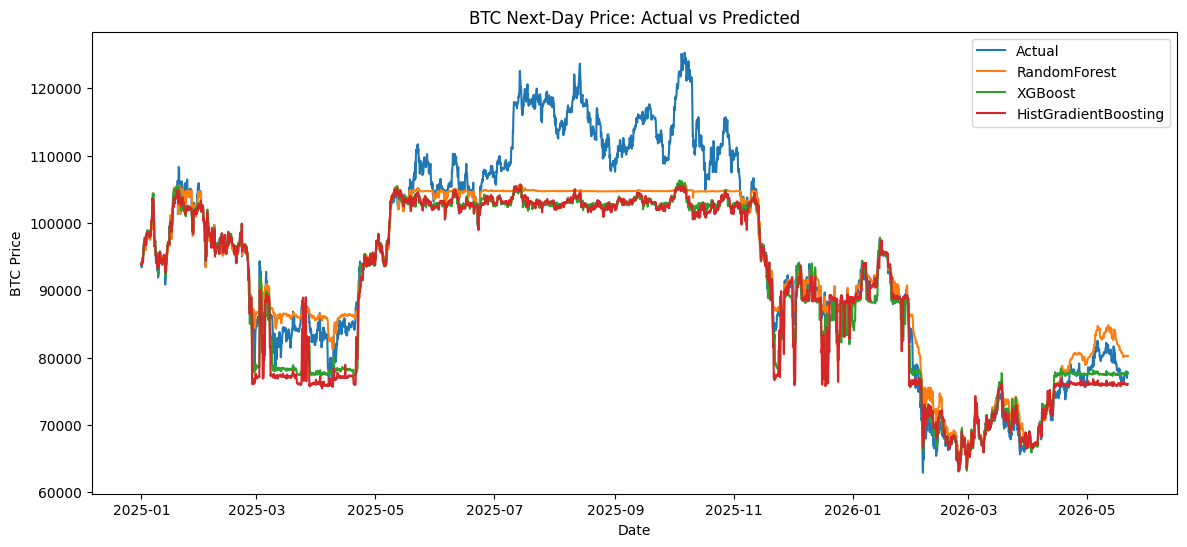

In [179]:
import matplotlib.pyplot as plt

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
hgb_pred = hgb_model.predict(X_test)

comparison_df = pd.DataFrame(index=X_test.index)

comparison_df["current_close"] = X_test["close"]
comparison_df["actual_future_price_1d"] = y_test
comparison_df["rf_predicted_price_1d"] = rf_pred
comparison_df["xgb_predicted_price_1d"] = xgb_pred
comparison_df["hgb_predicted_price_1d"] = hgb_pred

plt.figure(figsize=(14, 6))
plt.plot(comparison_df.index, comparison_df["actual_future_price_1d"], label="Actual")
plt.plot(comparison_df.index, comparison_df["rf_predicted_price_1d"], label="RandomForest")
plt.plot(comparison_df.index, comparison_df["xgb_predicted_price_1d"], label="XGBoost")
plt.plot(comparison_df.index, comparison_df["hgb_predicted_price_1d"], label="HistGradientBoosting")

plt.title("BTC Next-Day Price: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

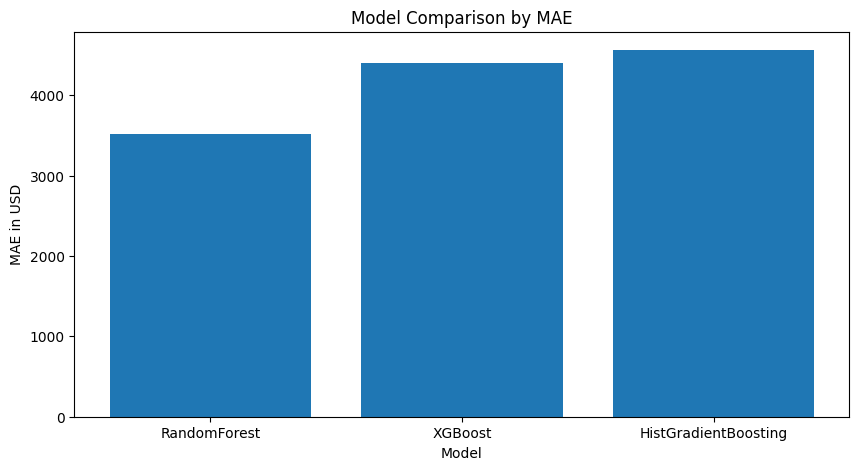

In [180]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["MAE"])

plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE in USD")
plt.show()

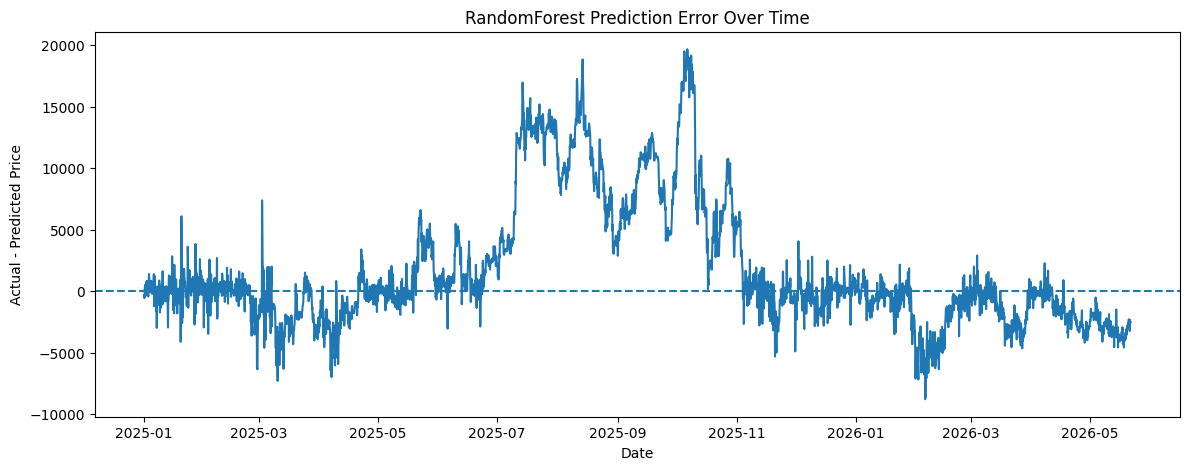

In [181]:
comparison_df["rf_error"] = (
    comparison_df["actual_future_price_1d"] -
    comparison_df["rf_predicted_price_1d"]
)

plt.figure(figsize=(14, 5))
plt.plot(comparison_df.index, comparison_df["rf_error"])

plt.axhline(0, linestyle="--")
plt.title("RandomForest Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted Price")
plt.show()

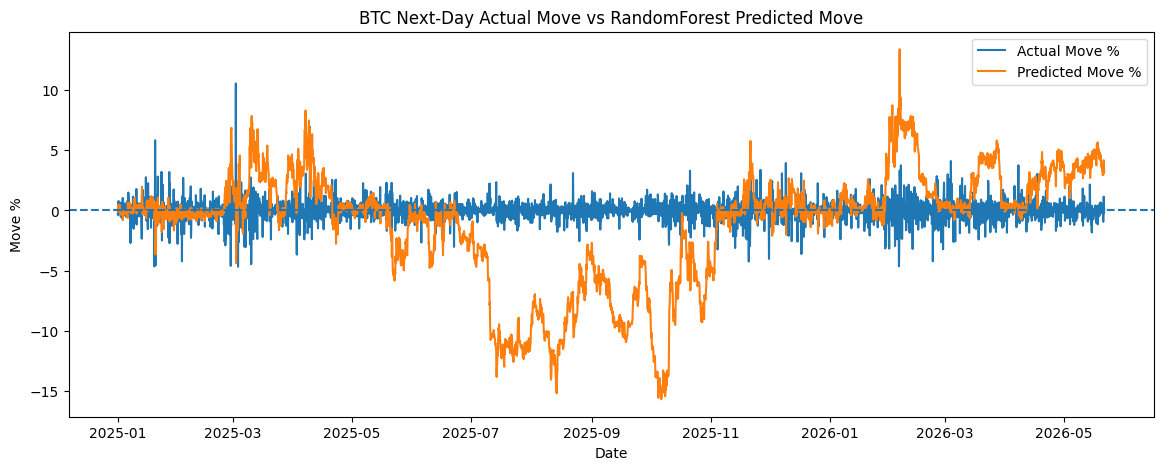

In [182]:
comparison_df["actual_move_%"] = (
    comparison_df["actual_future_price_1d"] /
    comparison_df["current_close"] - 1
) * 100

comparison_df["rf_predicted_move_%"] = (
    comparison_df["rf_predicted_price_1d"] /
    comparison_df["current_close"] - 1
) * 100

plt.figure(figsize=(14, 5))
plt.plot(comparison_df.index, comparison_df["actual_move_%"], label="Actual Move %")
plt.plot(comparison_df.index, comparison_df["rf_predicted_move_%"], label="Predicted Move %")

plt.axhline(0, linestyle="--")
plt.title("BTC Next-Day Actual Move vs RandomForest Predicted Move")
plt.xlabel("Date")
plt.ylabel("Move %")
plt.legend()
plt.show()

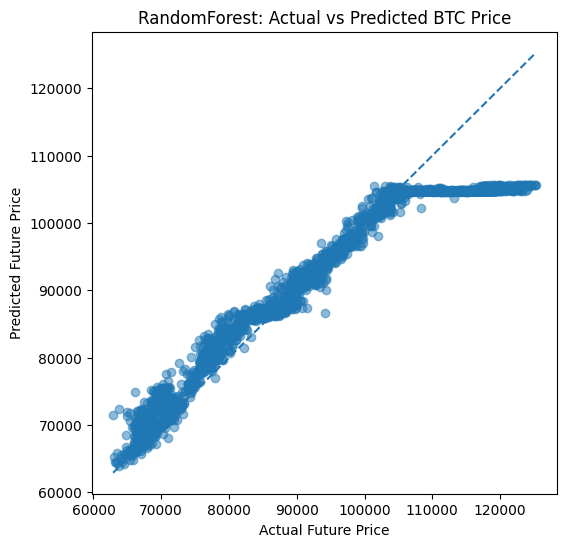

In [183]:
plt.figure(figsize=(6, 6))
plt.scatter(
    comparison_df["actual_future_price_1d"],
    comparison_df["rf_predicted_price_1d"],
    alpha=0.5
)

min_price = min(
    comparison_df["actual_future_price_1d"].min(),
    comparison_df["rf_predicted_price_1d"].min()
)

max_price = max(
    comparison_df["actual_future_price_1d"].max(),
    comparison_df["rf_predicted_price_1d"].max()
)

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.title("RandomForest: Actual vs Predicted BTC Price")
plt.xlabel("Actual Future Price")
plt.ylabel("Predicted Future Price")
plt.show()

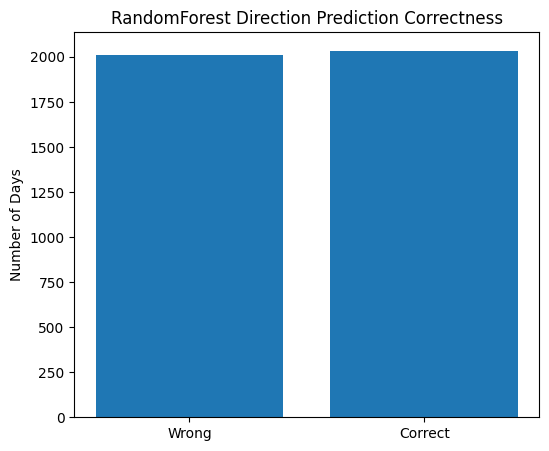

In [184]:
comparison_df["actual_direction"] = np.sign(
    comparison_df["actual_future_price_1d"] -
    comparison_df["current_close"]
)

comparison_df["rf_predicted_direction"] = np.sign(
    comparison_df["rf_predicted_price_1d"] -
    comparison_df["current_close"]
)

comparison_df["correct_direction"] = (
    comparison_df["actual_direction"] ==
    comparison_df["rf_predicted_direction"]
)

direction_counts = comparison_df["correct_direction"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(
    ["Wrong", "Correct"],
    [
        direction_counts.get(False, 0),
        direction_counts.get(True, 0)
    ]
)

plt.title("RandomForest Direction Prediction Correctness")
plt.ylabel("Number of Days")
plt.show()

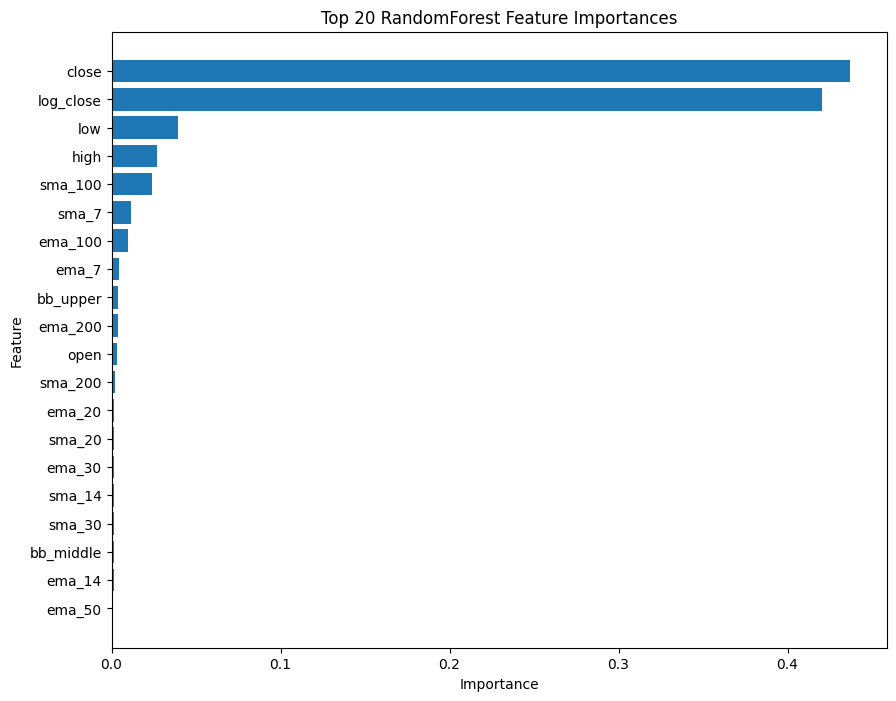

In [185]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

top_20 = importance_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_20["feature"], top_20["importance"])
plt.gca().invert_yaxis()

plt.title("Top 20 RandomForest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [186]:
# ❌ আপনার target এখন absolute price (যেমন 7242.85)
print(df['target'].describe())

KeyError: 'target'

In [187]:
import yfinance as yf
df_max = yf.download("BTC-USD", start="2010-01-01", auto_adjust=True)
print(f"Total rows: {len(df_max)}")

[*********************100%***********************]  1 of 1 completed

Total rows: 4298


In [191]:
# CSV হিসেবে save করুন
df_max.to_csv("btc_daily_features.csv")
print("✅ Saved: btc_daily_features.csv")

✅ Saved: btc_daily_features.csv


In [195]:
data = pd.read_csv('../bitcoin_data/raw/btc_daily_features.csv')

In [196]:
data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2014-09-17,457.3340148925781,468.17401123046875,452.4219970703125,465.864013671875,21056800
3,2014-09-18,424.44000244140625,456.8599853515625,413.10400390625,456.8599853515625,34483200
4,2014-09-19,394.7959899902344,427.8349914550781,384.5320129394531,424.1029968261719,37919700


In [198]:
df = data.iloc[2:]
print(df.head())

        Price               Close                High                 Low  \
2  2014-09-17   457.3340148925781  468.17401123046875   452.4219970703125   
3  2014-09-18  424.44000244140625   456.8599853515625     413.10400390625   
4  2014-09-19   394.7959899902344   427.8349914550781   384.5320129394531   
5  2014-09-20  408.90399169921875   423.2959899902344  389.88299560546875   
6  2014-09-21   398.8210144042969   412.4259948730469   393.1809997558594   

                Open    Volume  
2   465.864013671875  21056800  
3  456.8599853515625  34483200  
4  424.1029968261719  37919700  
5  394.6730041503906  36863600  
6  408.0849914550781  26580100  


In [199]:
df.to_csv("btc_daily_data.csv")
print("✅ Saved")

✅ Saved


In [201]:
import pandas as pd

df = pd.read_csv("/Users/rajibul/Downloads/Data-Science-Projects/Financial_Market_Crypto/bitcoin_data/raw/btc_daily_data.csv")

# Unnamed:0 এবং Price বাদ দিন, Price column কে date হিসেবে rename করুন
df = df.drop(columns=['Unnamed: 0'])
df = df.rename(columns={'Price': 'date'})

# date কে index বানান
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# column order ঠিক করুন
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(df.head(3))
print(df.shape)

                  Open        High         Low       Close    Volume
date                                                                
2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800
2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200
2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700
(4298, 5)


In [202]:
df.columns = df.columns.str.lower()
print(df.head(3))

                  open        high         low       close    volume
date                                                                
2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800
2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200
2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700


In [203]:
df.to_csv("btc_daily_clean.csv")
print("✅ Saved")

✅ Saved


In [1]:
import yfinance as yf
from datetime import date
from dateutil.relativedelta import relativedelta

# Date range: last 11 years
end_date = date.today()
start_date = end_date - relativedelta(years=11)

# Download daily BTC data
df = yf.download(
    "BTC-USD",
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    progress=False,
    multi_level_index=False
)

# Keep only required columns
df = df[["Open", "High", "Low", "Close", "Volume"]]

# Move Date from index to column
df = df.reset_index()

# Save CSV
df.to_csv("btc_daily_11_years.csv", index=False)

print(df.head())
print(df.tail())
print(df.columns)

        Date        Open        High         Low       Close    Volume
0 2015-06-27  243.548996  251.339005  243.117004  250.990005  20488600
1 2015-06-28  250.955002  251.171997  247.434006  249.011002  15137600
2 2015-06-29  248.720993  257.173004  248.580994  257.063995  34742900
3 2015-06-30  257.036011  267.867004  255.945999  263.071991  44533800
4 2015-07-01  263.345001  265.171997  255.774002  258.621002  27029800
           Date          Open          High           Low         Close  \
4013 2026-06-22  63240.789062  65544.000000  63233.531250  63952.105469   
4014 2026-06-23  63952.792969  64196.562500  61893.207031  62668.019531   
4015 2026-06-24  62663.031250  63097.757812  59029.855469  60995.132812   
4016 2026-06-25  60992.070312  61868.906250  58075.921875  59721.675781   
4017 2026-06-26  59712.054688  60647.187500  58269.125000  60016.429688   

           Volume  
4013  26561496819  
4014  29608942370  
4015  42644106535  
4016  40625024718  
4017  41502864671  
Ind